## ML Lab Experiment No. 01
### Title: Data preprocessing on raw dataset
### TY IT 24141027

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [3]:
df = pd.read_csv("C:\\Users\\SWARA\\Downloads\\TY\\Sem 5\\ML Lab\\Dataset\\Employee.csv")

print("Dataset shape:", df.shape)

df

Dataset shape: (148, 6)


,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


# Data Exploration

In [5]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 records:")
df.head()

Number of rows and columns:
(148, 6)

Column names:
['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender']

First 5 records:


,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [7]:
print("Missing values in each column:")
df.isna().sum()

Missing values in each column:


Company     8
Age        18
Salary     24
Place      14
Country     0
Gender      0
dtype: int64

In [8]:
print("Number of unique values in each column:")
df.nunique()

Number of unique values in each column:


Company     6
Age        29
Salary     40
Place      11
Country     1
Gender      2
dtype: int64

In [9]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
4


# 1. Handling Duplicates

In [10]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

df.drop_duplicates(inplace=True)

print("Duplicate rows after removal:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows before removal: 4
Duplicate rows after removal: 0
Dataset shape after removing duplicates: (144, 6)


In [11]:
df.reset_index(drop=True, inplace=True)

df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


# Inspecting Categorical Values

In [12]:
print("Unique Company values:")
print(df['Company'].unique())

print("\nUnique Age values:")
print(df['Age'].unique())

print("\nUnique Salary values:")
print(df['Salary'].unique())

print("\nUnique Place values:")
print(df['Place'].unique())

print("\nUnique Country values:")
print(df['Country'].unique())

print("\nUnique Gender values:")
print(df['Gender'].unique())

Unique Company values:
['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']

Unique Age values:
[20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]

Unique Salary values:
[  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]

Unique Place values:
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']

Unique Country values:
['India']

Unique Gender values:
[0 1]


# Correcting Inconsistent Values

In [13]:
df['Company'].replace('Infosys Pvt Lmt', 'Infosys', inplace=True)
df['Company'].replace('Tata Consultancy Services', 'TCS', inplace=True)
df['Company'].replace('CTS', 'Cognizant', inplace=True)
df['Company'].replace('Congnizant', 'Cognizant', inplace=True)

df['Place'].replace('Podicherry', 'Pondicherry', inplace=True)

print("Corrected Company values:")
print(df['Company'].unique())

print("\nCorrected Place values:")
print(df['Place'].unique())

Corrected Company values:
['TCS' 'Infosys' 'Cognizant' nan]

Corrected Place values:
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Pondicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']


# Statistical Analysis

In [14]:
df.describe()

,Age,Salary,Gender
count,127.000000,121.000000,144.000000
mean,30.527559,5283.471074,0.222222
std,11.114717,2585.373600,0.417191
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,33.000000,5000.000000,0.000000
75%,37.500000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [15]:
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


# Missing Values

In [16]:
print("Missing values before treatment:")
print(df.isna().sum())

Missing values before treatment:
Company     8
Age        17
Salary     23
Place      14
Country     0
Gender      0
dtype: int64


In [17]:
print("Mode of Company:")
print(df['Company'].mode()[0])

Mode of Company:
TCS


In [18]:
df['Company'].fillna(df['Company'].mode()[0], inplace=True)

print("Missing values after filling Company:")
print(df.isna().sum())

Missing values after filling Company:
Company     0
Age        17
Salary     23
Place      14
Country     0
Gender      0
dtype: int64


# Invalid Age Values

In [20]:
print("Records with Age = 0:")
df[df['Age'] == 0]

Records with Age = 0:


,Company,Age,Salary,Place,Country,Gender
87,Infosys,0.0,3030.0,Calcutta,India,0
91,TCS,0.0,3045.0,Delhi,India,0
100,Cognizant,0.0,2034.0,Pondicherry,India,0
106,TCS,0.0,9024.0,Chennai,India,1
110,Infosys,0.0,3234.0,Mumbai,India,0
120,Cognizant,0.0,1234.0,Calcutta,India,0


In [21]:
df['Age'].replace(0, np.nan, inplace=True)

print("Missing values after replacing Age = 0:")
print(df.isna().sum())

Missing values after replacing Age = 0:
Company     0
Age        23
Salary     23
Place      14
Country     0
Gender      0
dtype: int64


In [22]:
rounded_mean = round(df['Age'].mean(), 0)

print("Mean Age:", rounded_mean)

Mean Age: 32.0


In [23]:
df['Age'].fillna(rounded_mean, inplace=True)

print("Missing values after filling Age:")
print(df.isna().sum())

Missing values after filling Age:
Company     0
Age         0
Salary     23
Place      14
Country     0
Gender      0
dtype: int64


# Missing Salary

In [24]:
rounded_salary = round(df['Salary'].mean(), 0)

print("Mean Salary:", rounded_salary)

Mean Salary: 5283.0


In [25]:
df['Salary'].fillna(rounded_salary, inplace=True)

print("Missing values after filling Salary:")
print(df.isna().sum())

Missing values after filling Salary:
Company     0
Age         0
Salary      0
Place      14
Country     0
Gender      0
dtype: int64


# missing place

In [26]:
print("Mode of Place:")
print(df['Place'].mode()[0])

Mode of Place:
Mumbai


In [27]:
df['Place'].fillna(df['Place'].mode()[0], inplace=True)

print("Missing values after filling Place:")
print(df.isna().sum())

Missing values after filling Place:
Company    0
Age        0
Salary     0
Place      0
Country    0
Gender     0
dtype: int64


# Final Missing Values

In [28]:
print("Final missing-value count:")
print(df.isna().sum())

Final missing-value count:
Company    0
Age        0
Salary     0
Place      0
Country    0
Gender     0
dtype: int64


In [29]:
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,5283.0,Chennai,India,0
1,Infosys,30.0,5283.0,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
139,Infosys,22.0,8202.0,Mumbai,India,0
140,TCS,33.0,9024.0,Calcutta,India,1
141,Infosys,44.0,4034.0,Delhi,India,1
142,TCS,33.0,5034.0,Mumbai,India,1


# Outlier Detection

## 1. Age Outliers

In [30]:
q1_age = df['Age'].quantile(0.25)
q3_age = df['Age'].quantile(0.75)

iqr_age = q3_age - q1_age

lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

print("Q1:", q1_age)
print("Q3:", q3_age)
print("IQR:", iqr_age)
print("Lower Bound:", lower_age)
print("Upper Bound:", upper_age)

Q1: 23.75
Q3: 36.0
IQR: 12.25
Lower Bound: 5.375
Upper Bound: 54.375


In [31]:
age_outliers = df[
    (df['Age'] < lower_age) |
    (df['Age'] > upper_age)
]

print("Age outliers:")
age_outliers

Age outliers:


,Company,Age,Salary,Place,Country,Gender


## 2. Salary Outliers

In [33]:
q1_salary = df['Salary'].quantile(0.25)
q3_salary = df['Salary'].quantile(0.75)

iqr_salary = q3_salary - q1_salary

lower_salary = q1_salary - 1.5 * iqr_salary
upper_salary = q3_salary + 1.5 * iqr_salary

print("Q1:", q1_salary)
print("Q3:", q3_salary)
print("IQR:", iqr_salary)
print("Lower Bound:", lower_salary)
print("Upper Bound:", upper_salary)

Q1: 3045.0
Q3: 7084.0
IQR: 4039.0
Lower Bound: -3013.5
Upper Bound: 13142.5


In [34]:
salary_outliers = df[
    (df['Salary'] < lower_salary) |
    (df['Salary'] > upper_salary)
]

print("Salary outliers:")
salary_outliers

Salary outliers:


,Company,Age,Salary,Place,Country,Gender


## Visualize Outliers

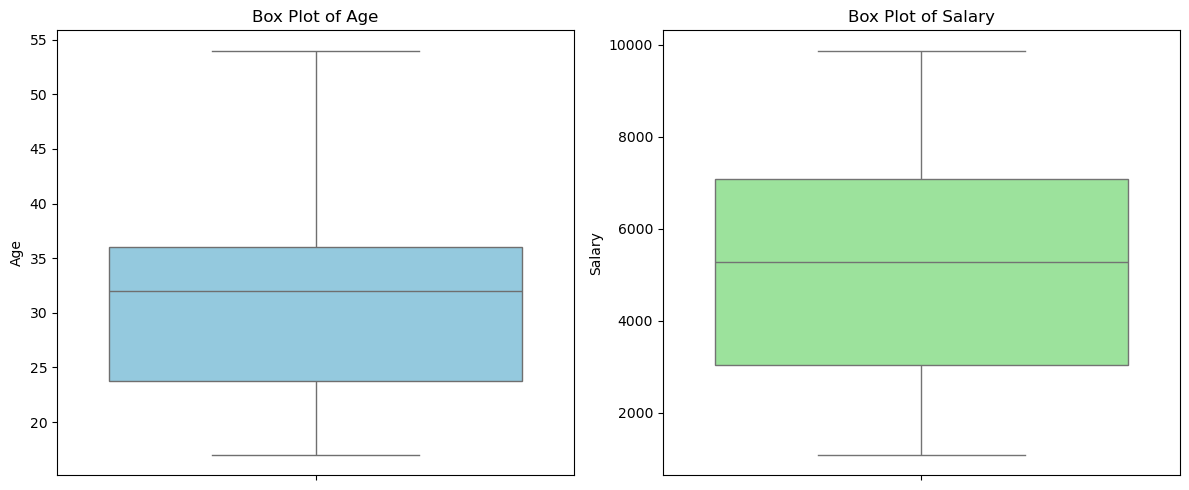

In [35]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'], color='skyblue')
plt.title('Box Plot of Age')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Salary'], color='lightgreen')
plt.title('Box Plot of Salary')

plt.tight_layout()
plt.show()

## Data Analysis

In [36]:
print("Employees with Age greater than 40 and Salary less than 5000:")

df[(df['Age'] > 40) & (df['Salary'] < 5000)]

Employees with Age greater than 40 and Salary less than 5000:


,Company,Age,Salary,Place,Country,Gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
85,Infosys,41.0,3000.0,Delhi,India,0
92,Infosys,54.0,3184.0,Mumbai,India,0
103,Infosys,44.0,4034.0,Delhi,India,0


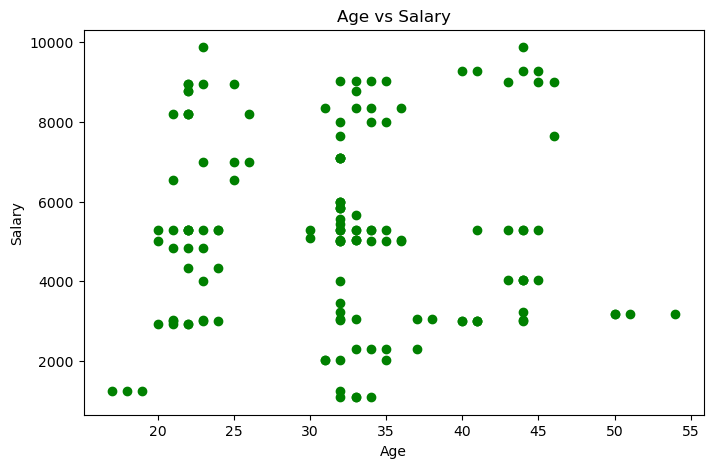

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Age'], df['Salary'], color='green')

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()

## Place Distribution

In [38]:
place_counts = df['Place'].value_counts()

print(place_counts)

Place
Mumbai         48
Calcutta       32
Chennai        14
Delhi          14
Cochin         13
Noida           8
Hyderabad       8
Pondicherry     3
Pune            2
Bhopal          1
Nagpur          1
Name: count, dtype: int64


In [39]:
x = place_counts.index
y = place_counts.values

print("Cities:")
print(x)

print("\nNumber of Employees:")
print(y)

Cities:
Index(['Mumbai', 'Calcutta', 'Chennai', 'Delhi', 'Cochin', 'Noida',
       'Hyderabad', 'Pondicherry', 'Pune', 'Bhopal', 'Nagpur'],
      dtype='object', name='Place')

Number of Employees:
[48 32 14 14 13  8  8  3  2  1  1]


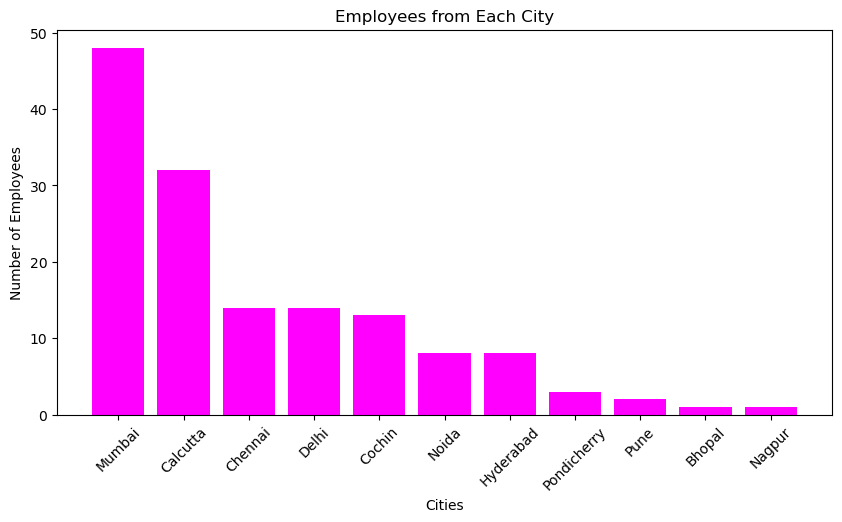

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(x, y, color='magenta')

plt.xlabel("Cities")
plt.ylabel("Number of Employees")
plt.title("Employees from Each City")

plt.xticks(rotation=45)

plt.show()

## Data Encoding

### 1. Gender Encoding

In [41]:
df['Gender'].replace(0, 'M', inplace=True)
df['Gender'].replace(1, 'F', inplace=True)

df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,5283.0,Chennai,India,M
1,Infosys,30.0,5283.0,Mumbai,India,M
2,TCS,35.0,2300.0,Calcutta,India,M
3,Infosys,40.0,3000.0,Delhi,India,M
4,TCS,23.0,4000.0,Mumbai,India,M


In [42]:
print("Gender value counts:")
print(df['Gender'].value_counts())

Gender value counts:
Gender
M    112
F     32
Name: count, dtype: int64


### 2. Remove Country

In [43]:
df.drop('Country', axis=1, inplace=True)

df

,Company,Age,Salary,Place,Gender
0,TCS,20.0,5283.0,Chennai,M
1,Infosys,30.0,5283.0,Mumbai,M
2,TCS,35.0,2300.0,Calcutta,M
3,Infosys,40.0,3000.0,Delhi,M
4,TCS,23.0,4000.0,Mumbai,M
...,...,...,...,...,...
139,Infosys,22.0,8202.0,Mumbai,M
140,TCS,33.0,9024.0,Calcutta,F
141,Infosys,44.0,4034.0,Delhi,F
142,TCS,33.0,5034.0,Mumbai,F


### One Hot Encoding

In [44]:
print("Unique Company values:")
print(df['Company'].unique())

print("\nUnique Place values:")
print(df['Place'].unique())

print("\nUnique Gender values:")
print(df['Gender'].unique())

Unique Company values:
['TCS' 'Infosys' 'Cognizant']

Unique Place values:
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Pondicherry' 'Cochin' 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']

Unique Gender values:
['M' 'F']


In [45]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [46]:
categorical_columns = ['Company', 'Place', 'Gender']

df_array = ohe.fit_transform(df[categorical_columns])

df_array

array([[0., 0., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 1.]])

In [47]:
print("Categories generated by OneHotEncoder:")

for column, categories in zip(categorical_columns, ohe.categories_):
    print(f"{column}: {categories}")

Categories generated by OneHotEncoder:
Company: ['Cognizant' 'Infosys' 'TCS']
Place: ['Bhopal' 'Calcutta' 'Chennai' 'Cochin' 'Delhi' 'Hyderabad' 'Mumbai'
 'Nagpur' 'Noida' 'Pondicherry' 'Pune']
Gender: ['F' 'M']


In [48]:
encoded_columns = ohe.get_feature_names_out(categorical_columns)

print("Encoded column names:")
print(encoded_columns)

Encoded column names:
['Company_Cognizant' 'Company_Infosys' 'Company_TCS' 'Place_Bhopal'
 'Place_Calcutta' 'Place_Chennai' 'Place_Cochin' 'Place_Delhi'
 'Place_Hyderabad' 'Place_Mumbai' 'Place_Nagpur' 'Place_Noida'
 'Place_Pondicherry' 'Place_Pune' 'Gender_F' 'Gender_M']


In [49]:
df_new = pd.DataFrame(
    df_array,
    columns=encoded_columns,
    index=df.index
)

df_new

,Company_Cognizant,Company_Infosys,Company_TCS,Place_Bhopal,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Pondicherry,Place_Pune,Gender_F,Gender_M
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
140,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
141,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
142,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [50]:
df_ml = pd.concat([df, df_new], axis=1)

df_ml

,Company,Age,Salary,Place,Gender,Company_Cognizant,Company_Infosys,Company_TCS,Place_Bhopal,Place_Calcutta,...,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Pondicherry,Place_Pune,Gender_F,Gender_M
0,TCS,20.0,5283.0,Chennai,M,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Infosys,30.0,5283.0,Mumbai,M,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,TCS,35.0,2300.0,Calcutta,M,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Infosys,40.0,3000.0,Delhi,M,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,TCS,23.0,4000.0,Mumbai,M,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Infosys,22.0,8202.0,Mumbai,M,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
140,TCS,33.0,9024.0,Calcutta,F,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
141,Infosys,44.0,4034.0,Delhi,F,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
142,TCS,33.0,5034.0,Mumbai,F,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### Label Encoding

In [51]:
df.to_csv('Employee_cleaned.csv', index=False)

print("Cleaned dataset saved as Employee_cleaned.csv")

Cleaned dataset saved as Employee_cleaned.csv


In [52]:
label = LabelEncoder()

print(label)

LabelEncoder()


In [53]:
df_sample = pd.read_csv('Employee_cleaned.csv')

df_sample['Company'] = label.fit_transform(df_sample['Company'])

df_sample

,Company,Age,Salary,Place,Gender
0,2,20.0,5283.0,Chennai,M
1,1,30.0,5283.0,Mumbai,M
2,2,35.0,2300.0,Calcutta,M
3,1,40.0,3000.0,Delhi,M
4,2,23.0,4000.0,Mumbai,M
...,...,...,...,...,...
139,1,22.0,8202.0,Mumbai,M
140,2,33.0,9024.0,Calcutta,F
141,1,44.0,4034.0,Delhi,F
142,2,33.0,5034.0,Mumbai,F


In [54]:
print("Company classes:")
print(label.classes_)

Company classes:
['Cognizant' 'Infosys' 'TCS']


### Standardization

In [65]:
from sklearn.preprocessing import StandardScaler



In [69]:
data = df[['Age', 'Salary']]

data

,Age,Salary
0,20.0,5283.0
1,30.0,5283.0
2,35.0,2300.0
3,40.0,3000.0
4,23.0,4000.0
...,...,...
139,22.0,8202.0
140,33.0,9024.0
141,44.0,4034.0
142,33.0,5034.0


In [70]:
scaler = StandardScaler()

scaler.fit(data)

print(scaler)

StandardScaler()


In [71]:
data_scaled=scaler.transform(data)

In [72]:
scaler = StandardScaler()

scaler.fit(data)

print(scaler)

StandardScaler()


In [73]:
print("Mean of standardized data:")
print(data_scaled.mean(axis=0))

print("\nStandard deviation of standardized data:")
print(data_scaled.std(axis=0))

Mean of standardized data:
[8.17247504e-17 1.03312420e-16]

Standard deviation of standardized data:
[1. 1.]


In [74]:
scaled_data_set = pd.DataFrame(
    data_scaled,
    columns=data.columns,
    index=data.index
)

scaled_data_set

,Age,Salary
0,-1.466569,-0.000168
1,-0.247954,-0.000168
2,0.361353,-1.264091
3,0.970661,-0.967495
4,-1.100985,-0.543786
...,...,...
139,-1.222846,1.236638
140,0.117630,1.584926
141,1.458106,-0.529380
142,0.117630,-0.105671


### Normalization using MinMax

In [75]:
data = df[['Age', 'Salary']]

data

,Age,Salary
0,20.0,5283.0
1,30.0,5283.0
2,35.0,2300.0
3,40.0,3000.0
4,23.0,4000.0
...,...,...
139,22.0,8202.0
140,33.0,9024.0
141,44.0,4034.0
142,33.0,5034.0


In [76]:
scaler = MinMaxScaler()

scaler.fit(data)

print(scaler)

MinMaxScaler()


In [77]:
print("Minimum values:")
print(scaler.data_min_)

print("\nMaximum values:")
print(scaler.data_max_)

print("\nFeature range:")
print(scaler.feature_range)

Minimum values:
[  17. 1089.]

Maximum values:
[  54. 9876.]

Feature range:
(0, 1)


In [78]:
data.describe()

,Age,Salary
count,144.000000,144.000000
mean,32.034722,5283.395833
std,8.234681,2368.350171
min,17.000000,1089.000000
25%,23.750000,3045.000000
50%,32.000000,5283.000000
75%,36.000000,7084.000000
max,54.000000,9876.000000


In [79]:
data_scaled_mm = scaler.transform(data)

print(data_scaled_mm)

[[0.08108108 0.47729601]
 [0.35135135 0.47729601]
 [0.48648649 0.13781723]
 [0.62162162 0.21748037]
 [0.16216216 0.33128485]
 [0.40540541 0.44508934]
 [0.40540541 0.55889382]
 [0.16216216 0.6726983 ]
 [0.45945946 0.78650279]
 [0.75675676 0.90030727]
 [0.16216216 0.47729601]
 [0.45945946 0.        ]
 [0.75675676 0.47729601]
 [0.02702703 0.01650165]
 [0.62162162 0.21748037]
 [0.16216216 0.21748037]
 [0.16216216 0.2208945 ]
 [0.45945946 0.44508934]
 [0.13513514 0.47729601]
 [0.40540541 0.47729601]
 [0.54054054 0.22260157]
 [0.89189189 0.23842039]
 [0.10810811 0.42505975]
 [0.40540541 0.54011608]
 [0.40540541 0.68225788]
 [0.16216216 0.89382042]
 [0.45945946 0.82576534]
 [0.75675676 0.93262775]
 [0.16216216 1.        ]
 [0.48648649 0.10754524]
 [0.78378378 0.74712644]
 [0.08108108 0.20996927]
 [0.75675676 0.33515421]
 [0.51351351 0.44895869]
 [0.24324324 0.80949129]
 [0.48648649 0.90303858]
 [0.40540541 0.47729601]
 [0.48648649 0.47729601]
 [0.45945946 0.13781723]
 [0.64864865 0.21748037]


In [80]:
mm_scaled_data_set = pd.DataFrame(
    data_scaled_mm,
    columns=data.columns,
    index=data.index
)

mm_scaled_data_set

,Age,Salary
0,0.081081,0.477296
1,0.351351,0.477296
2,0.486486,0.137817
3,0.621622,0.217480
4,0.162162,0.331285
...,...,...
139,0.135135,0.809491
140,0.432432,0.903039
141,0.729730,0.335154
142,0.432432,0.448959


## Z-score Normalization

In [86]:
data_zscore = df[['Age', 'Salary']]

data_zscore

,Age,Salary
0,20.0,5283.0
1,30.0,5283.0
2,35.0,2300.0
3,40.0,3000.0
4,23.0,4000.0
...,...,...
139,22.0,8202.0
140,33.0,9024.0
141,44.0,4034.0
142,33.0,5034.0


In [87]:
mean_values = data_zscore.mean()
std_values = data_zscore.std(ddof=0)

print("Mean of each feature:")
print(mean_values)

print("\nStandard deviation of each feature:")
print(std_values)

Mean of each feature:
Age         32.034722
Salary    5283.395833
dtype: float64

Standard deviation of each feature:
Age          8.206039
Salary    2360.112407
dtype: float64


In [88]:
zscore_data = (data_zscore - mean_values) / std_values

zscore_data

,Age,Salary
0,-1.466569,-0.000168
1,-0.247954,-0.000168
2,0.361353,-1.264091
3,0.970661,-0.967495
4,-1.100985,-0.543786
...,...,...
139,-1.222846,1.236638
140,0.117630,1.584926
141,1.458106,-0.529380
142,0.117630,-0.105671


In [89]:
print("Mean after Z-score normalization:")
print(zscore_data.mean())

print("\nStandard deviation after Z-score normalization:")
print(zscore_data.std(ddof=0))

Mean after Z-score normalization:
Age       7.093092e-17
Salary    1.187322e-16
dtype: float64

Standard deviation after Z-score normalization:
Age       1.0
Salary    1.0
dtype: float64


In [90]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

zscore_scaled = zscore_scaler.fit_transform(data_zscore)

zscore_scaled_data = pd.DataFrame(
    zscore_scaled,
    columns=data_zscore.columns,
    index=data_zscore.index
)

zscore_scaled_data

,Age,Salary
0,-1.466569,-0.000168
1,-0.247954,-0.000168
2,0.361353,-1.264091
3,0.970661,-0.967495
4,-1.100985,-0.543786
...,...,...
139,-1.222846,1.236638
140,0.117630,1.584926
141,1.458106,-0.529380
142,0.117630,-0.105671


In [91]:
print("Mean:")
print(zscore_scaled_data.mean())

print("\nStandard deviation:")
print(zscore_scaled_data.std(ddof=0))

Mean:
Age       8.172475e-17
Salary    1.033124e-16
dtype: float64

Standard deviation:
Age       1.0
Salary    1.0
dtype: float64


In [92]:
comparison = pd.DataFrame({
    'Original Age': data['Age'].values,
    'Original Salary': data['Salary'].values,
    'MinMax Age': mm_scaled_data_set['Age'].values,
    'MinMax Salary': mm_scaled_data_set['Salary'].values,
    'ZScore Age': zscore_data['Age'].values,
    'ZScore Salary': zscore_data['Salary'].values
})

comparison.head(10)

,Original Age,Original Salary,MinMax Age,MinMax Salary,ZScore Age,ZScore Salary
0,20.0,5283.0,0.081081,0.477296,-1.466569,-0.000168
1,30.0,5283.0,0.351351,0.477296,-0.247954,-0.000168
2,35.0,2300.0,0.486486,0.137817,0.361353,-1.264091
3,40.0,3000.0,0.621622,0.217480,0.970661,-0.967495
4,23.0,4000.0,0.162162,0.331285,-1.100985,-0.543786
5,32.0,5000.0,0.405405,0.445089,-0.004231,-0.120077
6,32.0,6000.0,0.405405,0.558894,-0.004231,0.303631
7,23.0,7000.0,0.162162,0.672698,-1.100985,0.727340
8,34.0,8000.0,0.459459,0.786503,0.239492,1.151049
9,45.0,9000.0,0.756757,0.900307,1.579968,1.574757


### Compare Scaling

In [81]:
print("Original Data:")
display(data.head())

print("\nStandardized Data:")
display(scaled_data_set.head())

print("\nNormalized Data:")
display(mm_scaled_data_set.head())

Original Data:


,Age,Salary
0,20.0,5283.0
1,30.0,5283.0
2,35.0,2300.0
3,40.0,3000.0
4,23.0,4000.0



Standardized Data:


,Age,Salary
0,-1.466569,-0.000168
1,-0.247954,-0.000168
2,0.361353,-1.264091
3,0.970661,-0.967495
4,-1.100985,-0.543786



Normalized Data:


,Age,Salary
0,0.081081,0.477296
1,0.351351,0.477296
2,0.486486,0.137817
3,0.621622,0.217480
4,0.162162,0.331285


### Verify Normalization

In [82]:
print("Minimum values after normalization:")
print(mm_scaled_data_set.min())

print("\nMaximum values after normalization:")
print(mm_scaled_data_set.max())

Minimum values after normalization:
Age       0.0
Salary    0.0
dtype: float64

Maximum values after normalization:
Age       1.0
Salary    1.0
dtype: float64


### Verify Standardization

In [83]:
print("Mean after standardization:")
print(scaled_data_set.mean())

print("\nStandard deviation after standardization:")
print(scaled_data_set.std(ddof=0))

Mean after standardization:
Age       8.172475e-17
Salary    1.033124e-16
dtype: float64

Standard deviation after standardization:
Age       1.0
Salary    1.0
dtype: float64


### Final Dataset

In [84]:
print("Final dataset shape:", df.shape)

print("\nFinal missing values:")
print(df.isna().sum())

print("\nFinal duplicate count:")
print(df.duplicated().sum())

print("\nFinal cleaned dataset:")
df.head(10)

Final dataset shape: (144, 5)

Final missing values:
Company    0
Age        0
Salary     0
Place      0
Gender     0
dtype: int64

Final duplicate count:
0

Final cleaned dataset:


,Company,Age,Salary,Place,Gender
0,TCS,20.0,5283.0,Chennai,M
1,Infosys,30.0,5283.0,Mumbai,M
2,TCS,35.0,2300.0,Calcutta,M
3,Infosys,40.0,3000.0,Delhi,M
4,TCS,23.0,4000.0,Mumbai,M
5,Infosys,32.0,5000.0,Calcutta,M
6,TCS,32.0,6000.0,Chennai,F
7,Infosys,23.0,7000.0,Mumbai,F
8,TCS,34.0,8000.0,Calcutta,F
9,Cognizant,45.0,9000.0,Delhi,M


In [85]:
df

,Company,Age,Salary,Place,Gender
0,TCS,20.0,5283.0,Chennai,M
1,Infosys,30.0,5283.0,Mumbai,M
2,TCS,35.0,2300.0,Calcutta,M
3,Infosys,40.0,3000.0,Delhi,M
4,TCS,23.0,4000.0,Mumbai,M
...,...,...,...,...,...
139,Infosys,22.0,8202.0,Mumbai,M
140,TCS,33.0,9024.0,Calcutta,F
141,Infosys,44.0,4034.0,Delhi,F
142,TCS,33.0,5034.0,Mumbai,F


## Conclusion

In this practical, data preprocessing techniques were successfully applied to the Employee dataset.

The preprocessing steps included:

- Loading and exploring the raw dataset.
- Detecting and removing duplicate records.
- Correcting inconsistent categorical values.
- Detecting and handling missing values.
- Identifying outliers using the IQR method.
- Visualizing the data using scatter plots, bar plots, and box plots.
- Encoding categorical variables using One-Hot Encoding and Label Encoding.
- Standardizing numerical features using StandardScaler.
- Normalizing numerical features using MinMaxScaler.

These preprocessing techniques improve the quality, consistency, and suitability of the dataset for further data analysis and machine learning applications.